In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

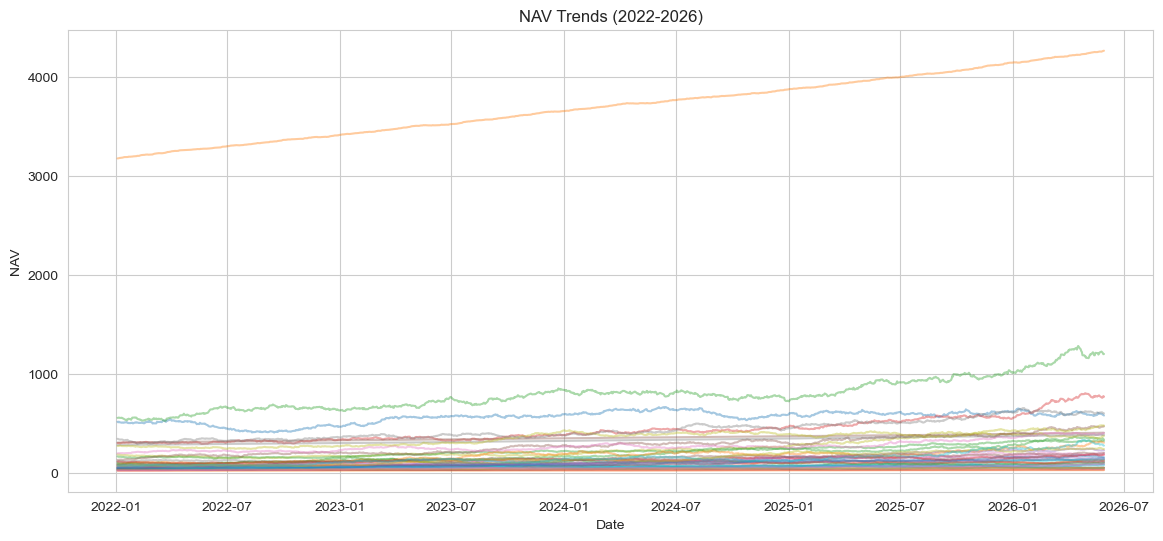

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(14,6))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], alpha=0.4)

plt.title("NAV Trends (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

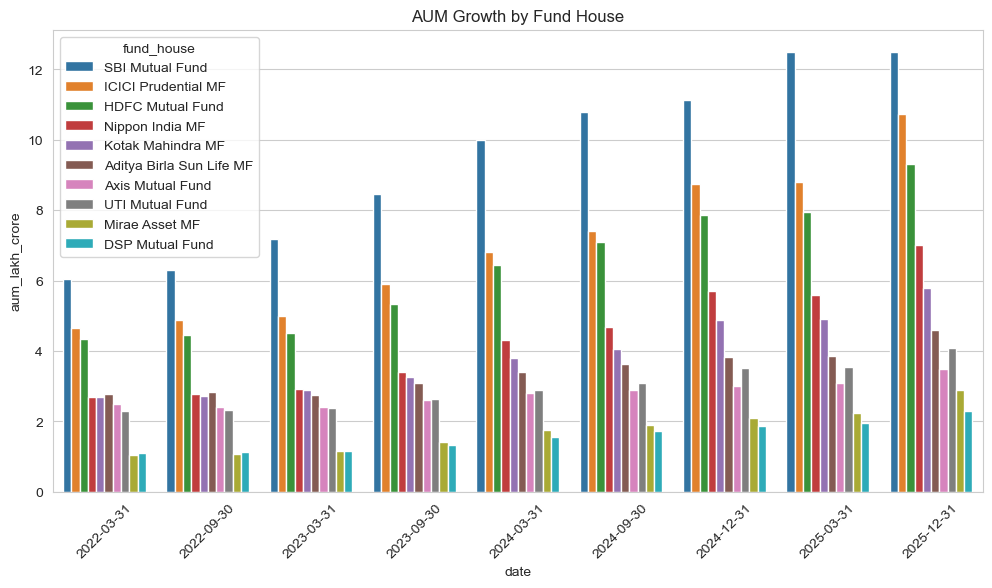

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

In [6]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.show()

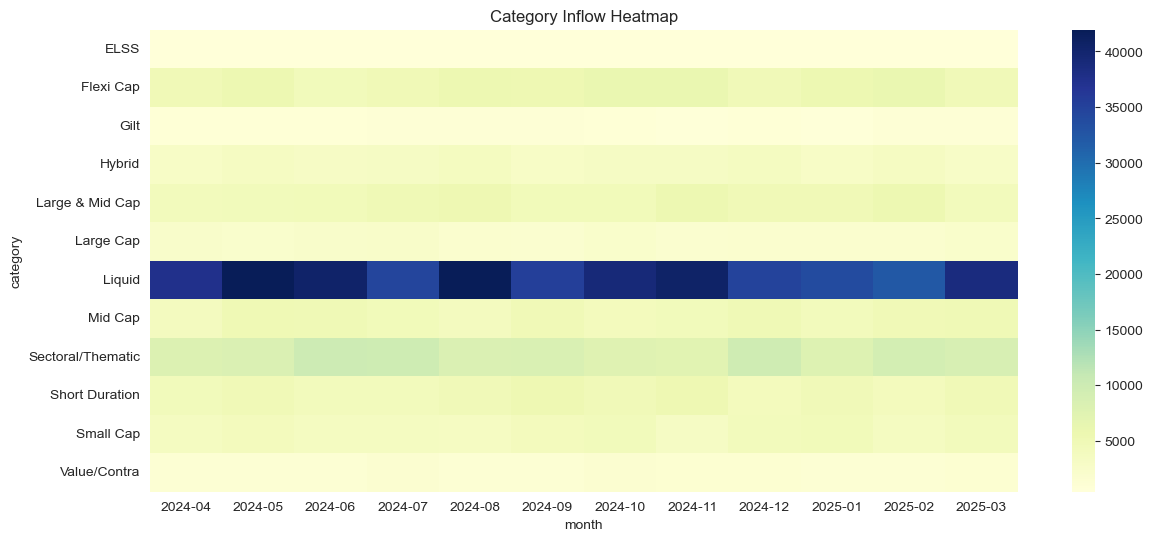

In [7]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

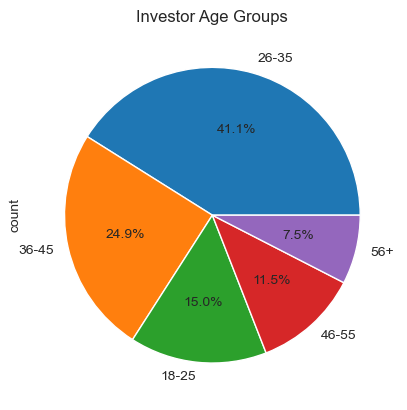

In [8]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Groups")

plt.show()

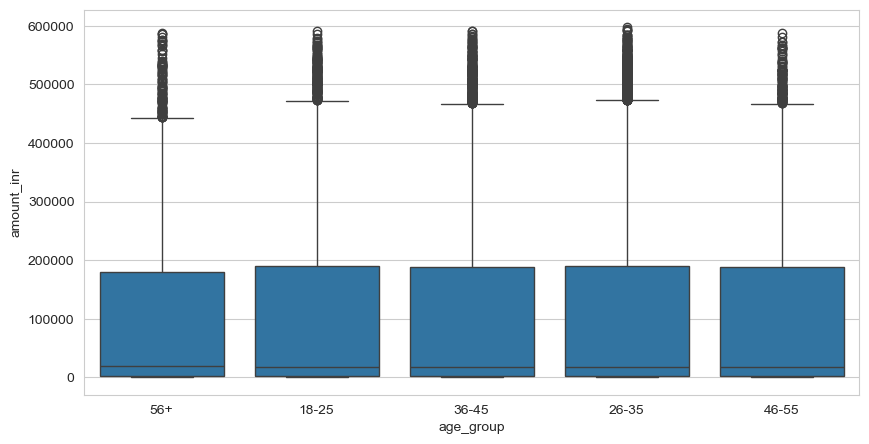

In [9]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.show()

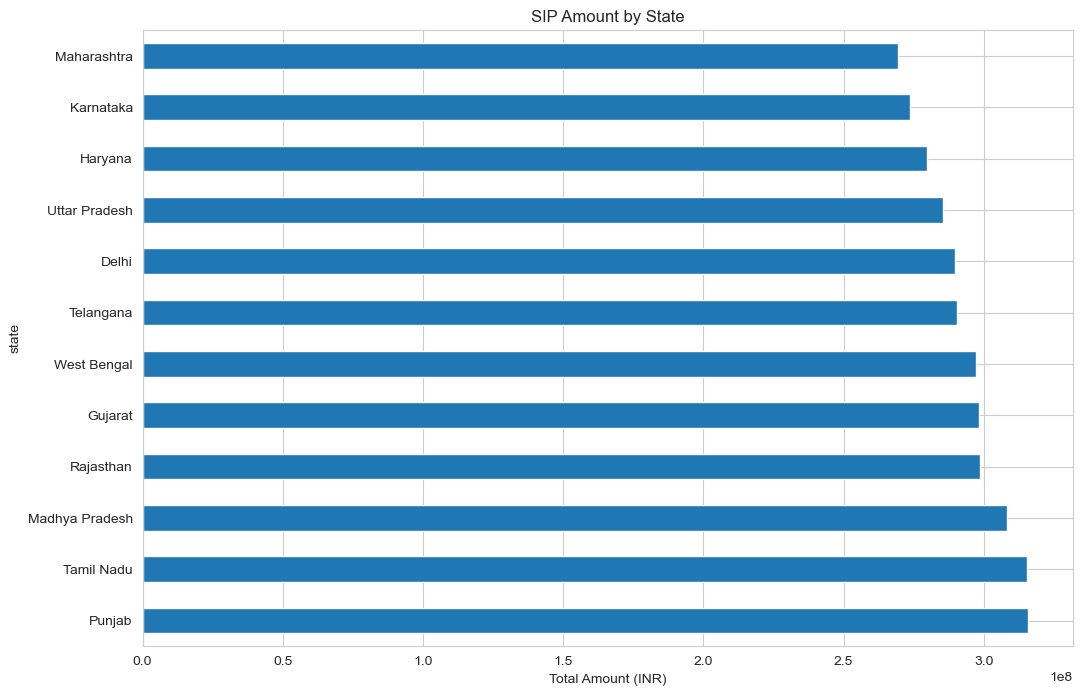

In [10]:
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_sip.plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("Total Amount (INR)")

plt.show()

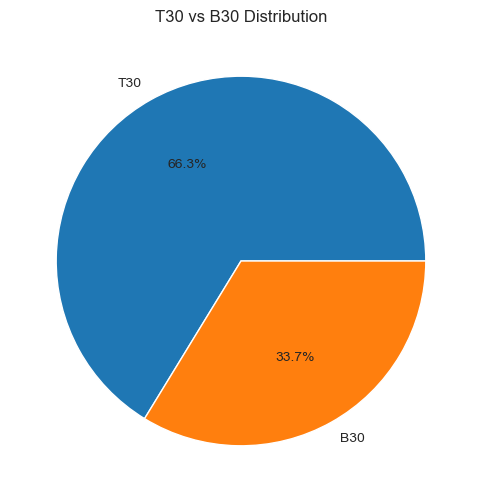

In [11]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.show()

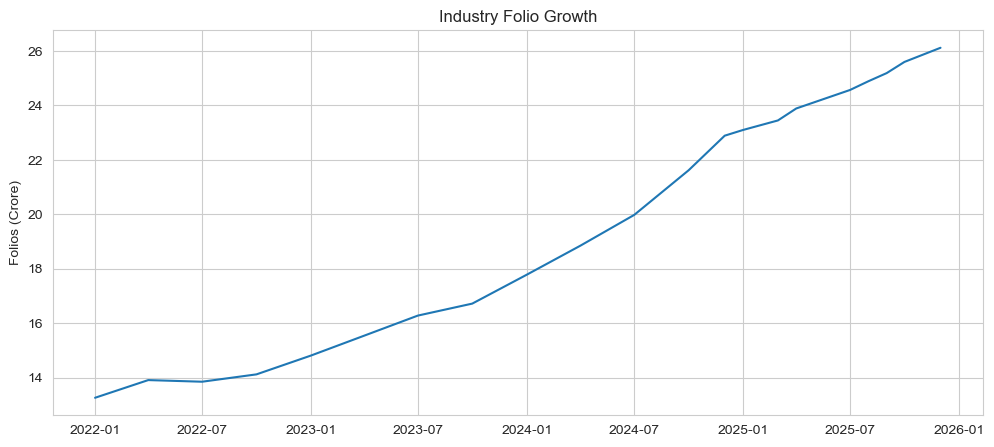

In [12]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.ylabel("Folios (Crore)")

plt.show()

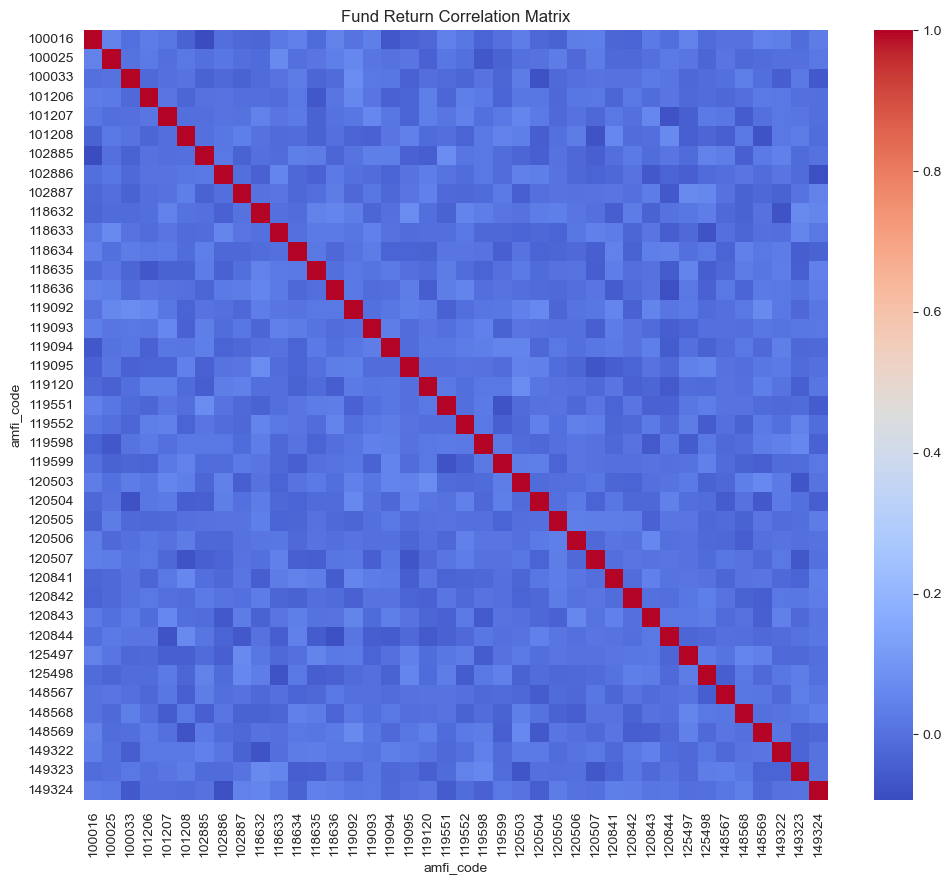

In [13]:
pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")

plt.show()

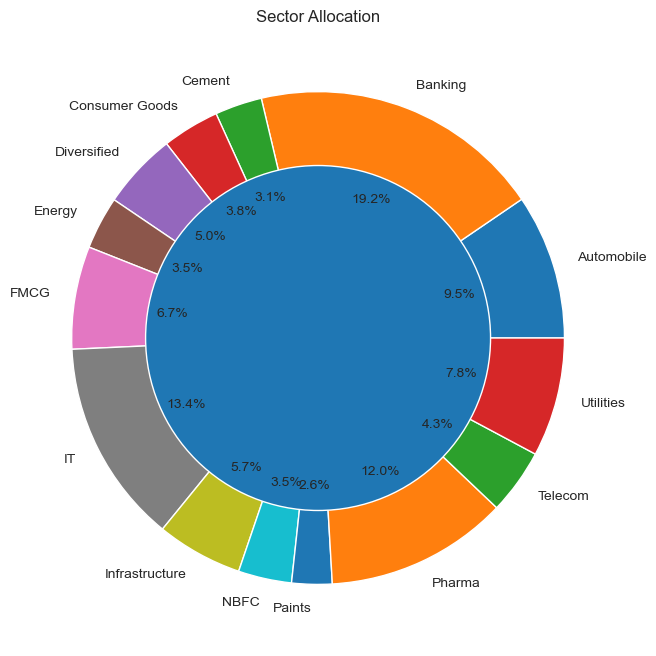

In [14]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

centre = plt.Circle((0,0),0.70)

fig = plt.gcf()
fig.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.show()

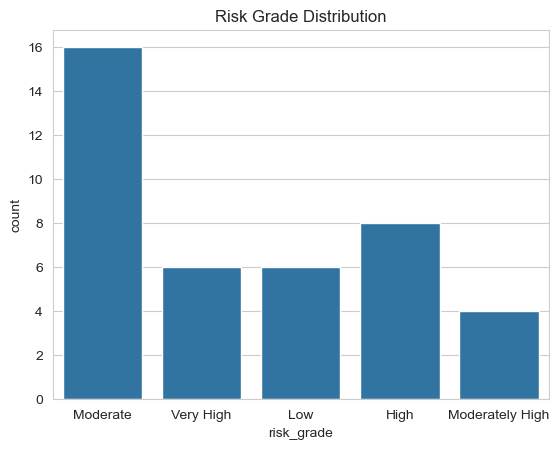

In [15]:
sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.show()

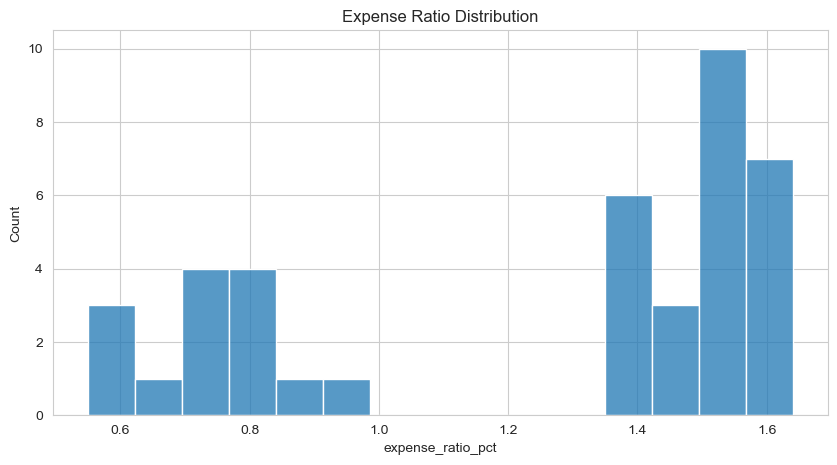

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15
)

plt.title("Expense Ratio Distribution")

plt.show()

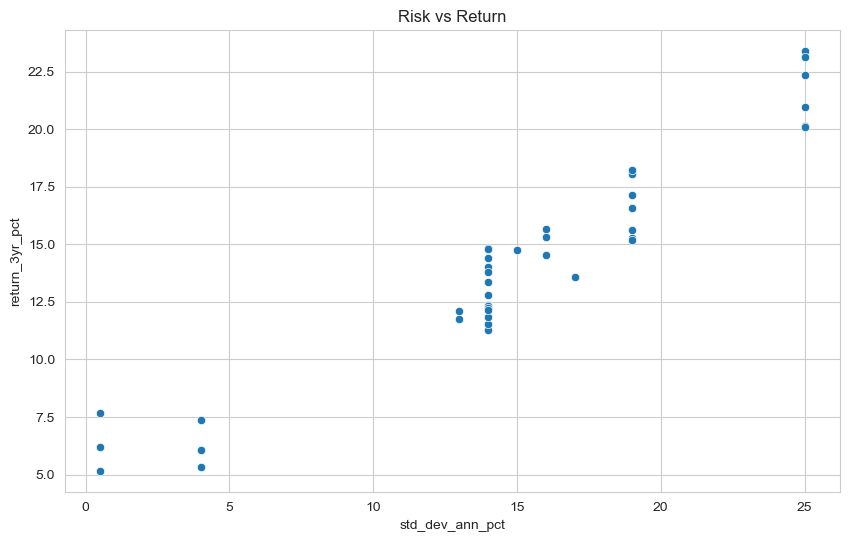

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_3yr_pct"
)

plt.title("Risk vs Return")

plt.show()

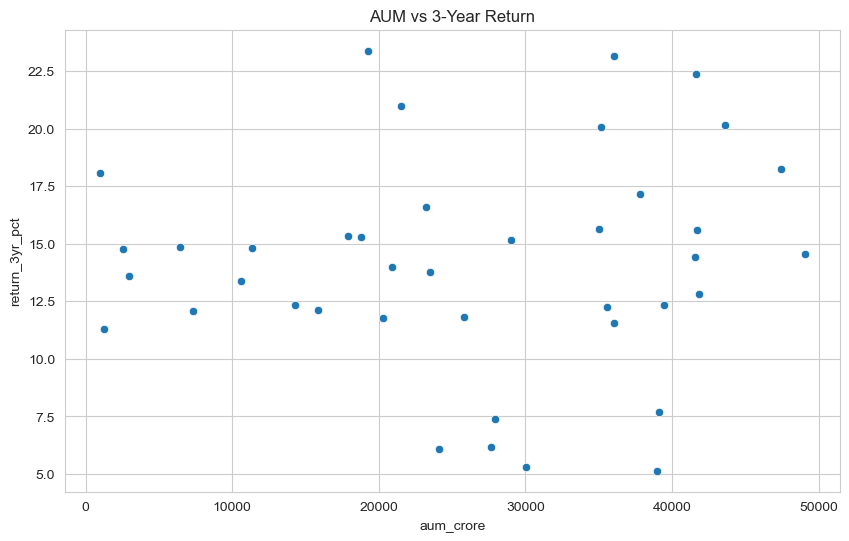

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="aum_crore",
    y="return_3yr_pct"
)

plt.title("AUM vs 3-Year Return")

plt.show()